# ChurnIQ: Telecom Customer Churn & Revenue Risk Analyzer

## Phase 3: Data Cleaning Strategy

### Objective

Design a systematic data cleaning strategy based on findings from the Data Understanding and Data Quality Assessment phases.

This notebook focuses on:

- Missing value treatment planning
- Hidden missing value handling
- Datatype correction planning
- Leakage handling decisions
- Cleaning recommendations

No cleaning implementation will be performed in this notebook.

##  Import Libraries

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
import pandas as pd

train_df = pd.read_csv("../data/raw/cell2celltrain.csv")
holdout_df = pd.read_csv("../data/raw/cell2cellholdout.csv")

## 1. Data Quality Issues Identified

In [3]:
issues = {
    "Missing Values": [
        "AgeHH1",
        "AgeHH2",
        "PercChangeMinutes",
        "PercChangeRevenues",
        "MonthlyRevenue",
        "MonthlyMinutes",
        "TotalRecurringCharge",
        "DirectorAssistedCalls",
        "OverageMinutes",
        "RoamingCalls"
    ],

    "Hidden Missing Values": [
        "MaritalStatus",
        "Homeownership",
        "HandsetPrice"
    ],

    "Datatype Issues": [
        "HandsetPrice"
    ],

    "Leakage Risk Features": [
        "RetentionCalls",
        "RetentionOffersAccepted",
        "MadeCallToRetentionTeam"
    ]
}

issues

{'Missing Values': ['AgeHH1',
  'AgeHH2',
  'PercChangeMinutes',
  'PercChangeRevenues',
  'MonthlyRevenue',
  'MonthlyMinutes',
  'TotalRecurringCharge',
  'DirectorAssistedCalls',
  'OverageMinutes',
  'RoamingCalls'],
 'Hidden Missing Values': ['MaritalStatus', 'Homeownership', 'HandsetPrice'],
 'Datatype Issues': ['HandsetPrice'],
 'Leakage Risk Features': ['RetentionCalls',
  'RetentionOffersAccepted',
  'MadeCallToRetentionTeam']}

## 2. Missing Value Pattern Investigation

### Objective

Determine whether missing values occur independently or appear together across multiple variables.

In [4]:
missing_rows = train_df[
    train_df["MonthlyRevenue"].isnull()
]

missing_rows.shape

(156, 58)

In [5]:
missing_rows[
    [
        "MonthlyRevenue",
        "MonthlyMinutes",
        "TotalRecurringCharge",
        "DirectorAssistedCalls",
        "OverageMinutes",
        "RoamingCalls"
    ]
].isnull().sum()

MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
dtype: int64

### Observation

A group of 156 customers is missing multiple usage and revenue-related variables simultaneously.

The missing values do not appear to be random and may represent a specific customer segment or data collection issue.

This pattern should be considered when designing imputation strategies.

## 3. Preliminary Cleaning Strategy

In [6]:
cleaning_strategy = {
    "AgeHH1": "Impute",
    "AgeHH2": "Impute",
    "PercChangeMinutes": "Impute",
    "PercChangeRevenues": "Impute",

    "MonthlyRevenue": "Investigate Pattern Then Impute",
    "MonthlyMinutes": "Investigate Pattern Then Impute",
    "TotalRecurringCharge": "Investigate Pattern Then Impute",
    "DirectorAssistedCalls": "Investigate Pattern Then Impute",
    "OverageMinutes": "Investigate Pattern Then Impute",
    "RoamingCalls": "Investigate Pattern Then Impute",

    "HandsetPrice": "Convert Unknown and Correct Datatype",

    "MaritalStatus": "Treat Unknown as Category",

    "Homeownership": "Investigate Business Meaning",

    "RetentionCalls": "Leakage Review Required",
    "RetentionOffersAccepted": "Leakage Review Required",
    "MadeCallToRetentionTeam": "Leakage Review Required"
}

cleaning_strategy

{'AgeHH1': 'Impute',
 'AgeHH2': 'Impute',
 'PercChangeMinutes': 'Impute',
 'PercChangeRevenues': 'Impute',
 'MonthlyRevenue': 'Investigate Pattern Then Impute',
 'MonthlyMinutes': 'Investigate Pattern Then Impute',
 'TotalRecurringCharge': 'Investigate Pattern Then Impute',
 'DirectorAssistedCalls': 'Investigate Pattern Then Impute',
 'OverageMinutes': 'Investigate Pattern Then Impute',
 'RoamingCalls': 'Investigate Pattern Then Impute',
 'HandsetPrice': 'Convert Unknown and Correct Datatype',
 'MaritalStatus': 'Treat Unknown as Category',
 'Homeownership': 'Investigate Business Meaning',
 'RetentionCalls': 'Leakage Review Required',
 'RetentionOffersAccepted': 'Leakage Review Required',
 'MadeCallToRetentionTeam': 'Leakage Review Required'}

## 4. Numerical Feature Distribution Assessment

### Objective

Evaluate numerical feature distributions before selecting imputation strategies.

In [7]:
train_df[["AgeHH1", "AgeHH2"]].describe()

,AgeHH1,AgeHH2
count,50138.000000,50138.000000
mean,31.338127,21.144142
std,22.094635,23.931368
min,0.000000,0.000000
25%,0.000000,0.000000
50%,36.000000,0.000000
75%,48.000000,42.000000
max,99.000000,99.000000


<Axes: >

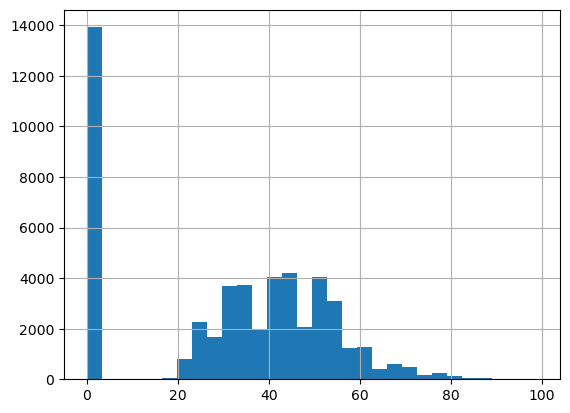

In [8]:
train_df["AgeHH1"].hist(bins=30)

<Axes: >

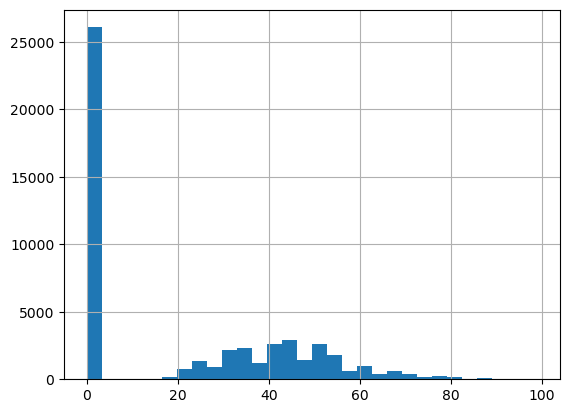

In [9]:
train_df["AgeHH2"].hist(bins=30)

In [10]:
train_df[["AgeHH1", "AgeHH2"]].describe()

,AgeHH1,AgeHH2
count,50138.000000,50138.000000
mean,31.338127,21.144142
std,22.094635,23.931368
min,0.000000,0.000000
25%,0.000000,0.000000
50%,36.000000,0.000000
75%,48.000000,42.000000
max,99.000000,99.000000


## 5. Age Feature Investigation

### Objective

Determine whether age values of 0 represent valid ages or hidden missing values.

In [11]:
(train_df["AgeHH1"] == 0).sum()

np.int64(13917)

In [12]:
(train_df["AgeHH2"] == 0).sum()

np.int64(26087)

In [13]:
(train_df["AgeHH1"] == 0).mean() * 100

np.float64(27.263110466824692)

In [14]:
(train_df["AgeHH2"] == 0).mean() * 100

np.float64(51.10388465531764)

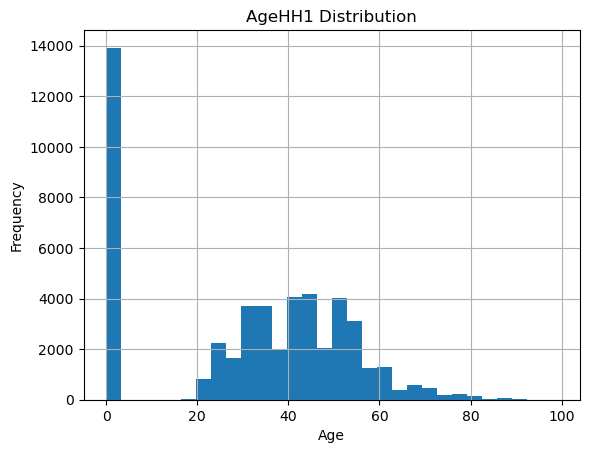

In [15]:
import matplotlib.pyplot as plt

train_df["AgeHH1"].hist(bins=30)

plt.title("AgeHH1 Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Key Finding

AgeHH1 and AgeHH2 contain a large number of zero values.

Given the business context, these values are unlikely to represent valid ages and are likely encoded missing values.

AgeHH1:
- 27.26% values are 0

AgeHH2:
- 51.10% values are 0

These features require special handling during the cleaning phase.

In [16]:
agehh2_missing_after_zero = (
    train_df["AgeHH2"].isnull() |
    (train_df["AgeHH2"] == 0)
).mean() * 100

agehh2_missing_after_zero

np.float64(52.88459654827904)

In [17]:
agehh1_missing_after_zero = (
    train_df["AgeHH1"].isnull() |
    (train_df["AgeHH1"] == 0)
).mean() * 100

agehh1_missing_after_zero

np.float64(29.04382235978608)

### Age Feature Assessment

AgeHH1:
- Effective missingness ≈ 29%
- Candidate for retention and imputation

AgeHH2:
- Effective missingness ≈ 53%
- Requires further evaluation before deciding whether to retain or remove

Final decisions will be made after feature importance analysis and modeling experiments.

In [18]:
strategy_df = pd.DataFrame({
    "Feature": [
        "AgeHH1",
        "AgeHH2",
        "HandsetPrice",
        "MaritalStatus",
        "Homeownership",
        "RetentionCalls",
        "RetentionOffersAccepted",
        "MadeCallToRetentionTeam"
    ],

    "Issue": [
        "Hidden Missing Values",
        "Hidden Missing Values",
        "Datatype + Unknown Values",
        "Unknown Category",
        "Unknown Category",
        "Leakage Risk",
        "Leakage Risk",
        "Leakage Risk"
    ],

    "Proposed Action": [
        "Convert 0 to NaN, then impute",
        "Evaluate before retain/drop",
        "Convert Unknown to NaN and numeric",
        "Treat Unknown as category",
        "Investigate business meaning",
        "Review during modeling",
        "Review during modeling",
        "Review during modeling"
    ]
})

strategy_df

,Feature,Issue,Proposed Action
0,AgeHH1,Hidden Missing Values,"Convert 0 to NaN, then impute"
1,AgeHH2,Hidden Missing Values,Evaluate before retain/drop
2,HandsetPrice,Datatype + Unknown Values,Convert Unknown to NaN and numeric
3,MaritalStatus,Unknown Category,Treat Unknown as category
4,Homeownership,Unknown Category,Investigate business meaning
5,RetentionCalls,Leakage Risk,Review during modeling
6,RetentionOffersAccepted,Leakage Risk,Review during modeling
7,MadeCallToRetentionTeam,Leakage Risk,Review during modeling


## 6. Final Cleaning Strategy Summary

The following table summarizes all identified data quality issues and proposed treatments.

In [19]:
final_strategy_df = pd.DataFrame({

    "Feature": [
        "AgeHH1",
        "AgeHH2",
        "PercChangeMinutes",
        "PercChangeRevenues",
        "MonthlyRevenue",
        "MonthlyMinutes",
        "TotalRecurringCharge",
        "DirectorAssistedCalls",
        "OverageMinutes",
        "RoamingCalls",
        "HandsetPrice",
        "MaritalStatus",
        "Homeownership",
        "RetentionCalls",
        "RetentionOffersAccepted",
        "MadeCallToRetentionTeam"
    ],

    "Issue": [
        "Hidden Missing Values",
        "Hidden Missing Values",
        "Missing Values",
        "Missing Values",
        "Structured Missingness",
        "Structured Missingness",
        "Structured Missingness",
        "Structured Missingness",
        "Structured Missingness",
        "Structured Missingness",
        "Datatype + Unknown Values",
        "Unknown Category",
        "Unknown Category",
        "Leakage Risk",
        "Leakage Risk",
        "Leakage Risk"
    ],

    "Proposed Action": [
        "Convert 0 to NaN then impute",
        "Evaluate before retain/drop",
        "Median imputation candidate",
        "Median imputation candidate",
        "Investigate pattern then impute",
        "Investigate pattern then impute",
        "Investigate pattern then impute",
        "Investigate pattern then impute",
        "Investigate pattern then impute",
        "Investigate pattern then impute",
        "Convert Unknown to NaN and numeric",
        "Treat Unknown as category",
        "Investigate business meaning",
        "Review during modeling",
        "Review during modeling",
        "Review during modeling"
    ]
})

final_strategy_df

,Feature,Issue,Proposed Action
0,AgeHH1,Hidden Missing Values,Convert 0 to NaN then impute
1,AgeHH2,Hidden Missing Values,Evaluate before retain/drop
2,PercChangeMinutes,Missing Values,Median imputation candidate
3,PercChangeRevenues,Missing Values,Median imputation candidate
4,MonthlyRevenue,Structured Missingness,Investigate pattern then impute
5,MonthlyMinutes,Structured Missingness,Investigate pattern then impute
6,TotalRecurringCharge,Structured Missingness,Investigate pattern then impute
7,DirectorAssistedCalls,Structured Missingness,Investigate pattern then impute
8,OverageMinutes,Structured Missingness,Investigate pattern then impute
9,RoamingCalls,Structured Missingness,Investigate pattern then impute


## Conclusion

Key findings from the cleaning strategy phase:

- Missing values are generally low across the dataset.
- AgeHH1 and AgeHH2 contain hidden missing values encoded as 0.
- A group of 156 customers exhibits structured missingness across multiple usage-related variables.
- HandsetPrice requires datatype correction and missing value handling.
- Several retention-related features require leakage assessment before modeling.
- No duplicate records or duplicate CustomerIDs were identified.

The cleaning implementation will be performed in the next phase using the strategy defined in this notebook.